In [1]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_zarr('../datasets/rain-gauge-adjusted-radar-data.zarr')
print(ds)  # see what's in there

<xarray.Dataset> Size: 113GB
Dimensions:     (time: 5844, variable: 9, ensemble: 1, cell: 535500)
Dimensions without coordinates: time, variable, ensemble, cell
Data variables:
    data        (time, variable, ensemble, cell) float32 113GB dask.array<chunksize=(1, 9, 1, 535500), meta=np.ndarray>
    dates       (time) datetime64[s] 47kB dask.array<chunksize=(5844,), meta=np.ndarray>
    latitudes   (cell) float64 4MB dask.array<chunksize=(66938,), meta=np.ndarray>
    longitudes  (cell) float64 4MB dask.array<chunksize=(66938,), meta=np.ndarray>
    maximum     (variable) float64 72B dask.array<chunksize=(9,), meta=np.ndarray>
    mean        (variable) float64 72B dask.array<chunksize=(9,), meta=np.ndarray>
    minimum     (variable) float64 72B dask.array<chunksize=(9,), meta=np.ndarray>
    stdev       (variable) float64 72B dask.array<chunksize=(9,), meta=np.ndarray>
Attributes: (12/32)
    allow_nans:              False
    attribution:             unknown
    chunks:             

/tmp/ipykernel_1238717/208609534.py:4: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr('../datasets/rain-gauge-adjusted-radar-data.zarr')


In [2]:
data = ds['data'][:,8,:,:].squeeze()
# data = ds['data'].squeeze()

In [ ]:
mean_precip = data.mean(dim='time').compute()
mean_2d = mean_precip.values.reshape(765, 700)

In [11]:
import numpy as np

lats = ds['latitudes'].compute().values
lons = ds['longitudes'].compute().values
lons = np.nan_to_num(lons, nan=0.0)

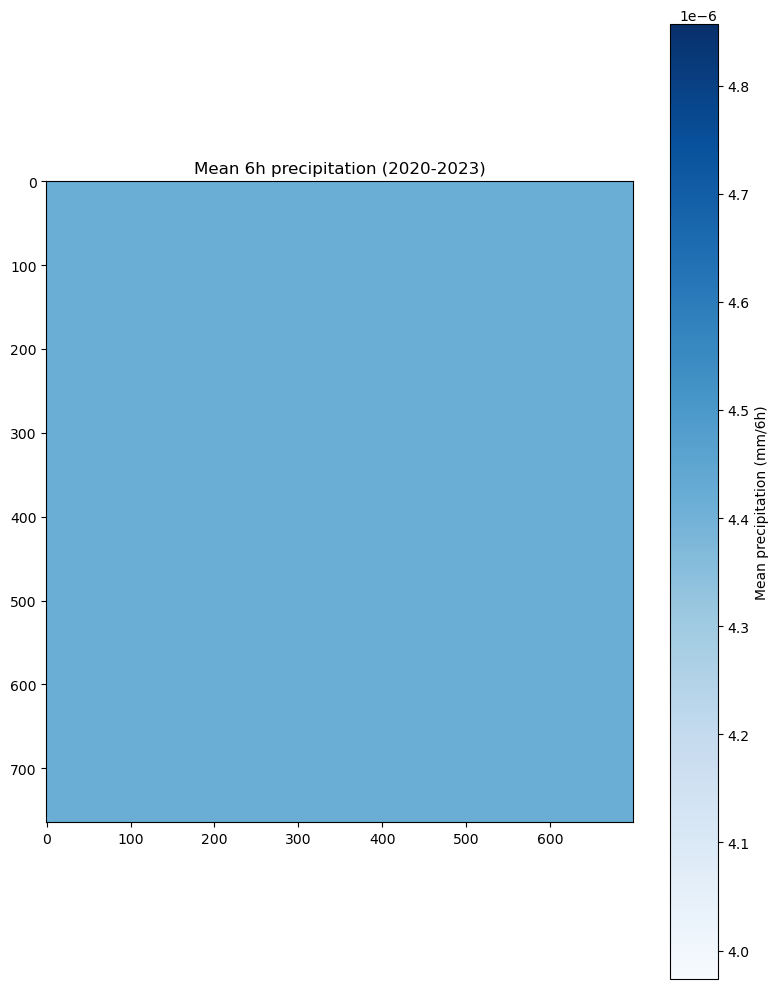

In [ ]:
fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(
    mean_2d,
    cmap='turbo',
    origin='upper',
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    aspect=1 / np.cos(np.radians(52))
)
ax.set_xlim(3, 8)
ax.set_ylim(50, 54)
plt.colorbar(im, ax=ax, label='Max precipitation (mm/6h)')
ax.set_title('Max 6h precipitation (2020-2023)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('max_precip_heatmap.png', dpi=150)
plt.show()
# fig, ax = plt.subplots(figsize=(8, 10))
# im = ax.imshow(mean_precip, cmap='Blues', origin='upper', aspect='equal')
# plt.colorbar(im, ax=ax, label='Mean precipitation (mm/6h)')
# ax.set_title('Mean 6h precipitation (2020-2023)')
# plt.tight_layout()
# plt.savefig('mean_precip_heatmap_turbo.png', dpi=150)
# plt.show()

In [3]:
max_precip = data.max(dim='time').compute().values

max_2d = max_precip.reshape(765, 700)

/usr/people/haar/.local/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


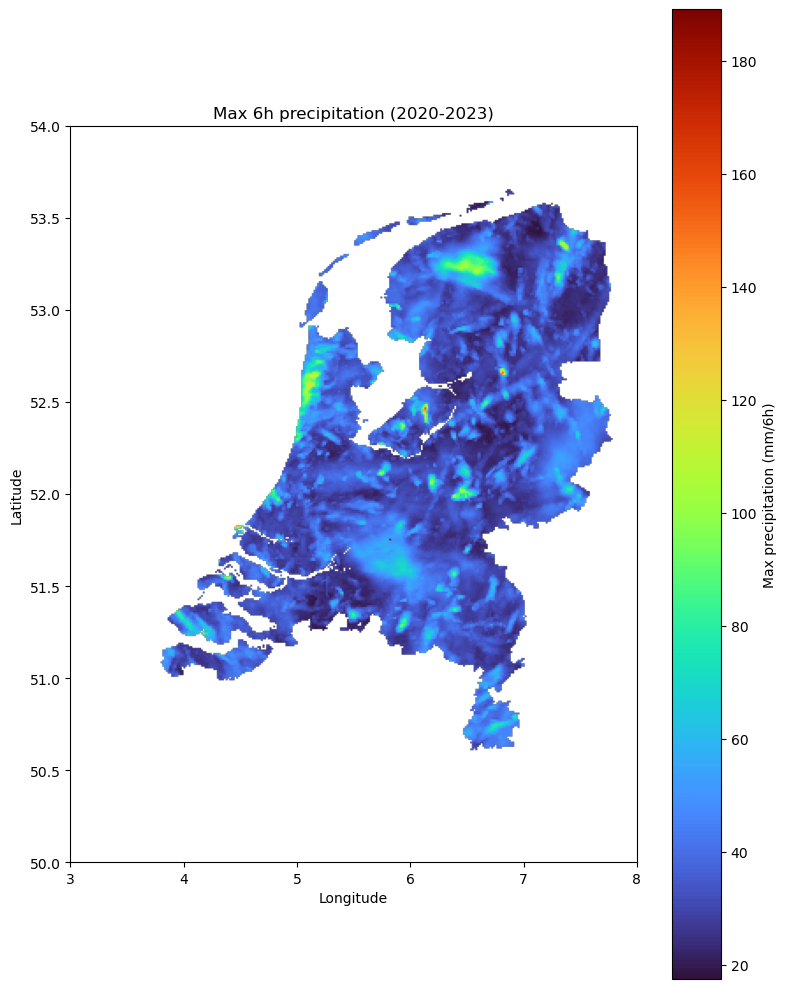

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(
    max_2d,
    cmap='turbo',
    origin='upper',
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    aspect=1 / np.cos(np.radians(52))
)
ax.set_xlim(3, 8)
ax.set_ylim(50, 54)
plt.colorbar(im, ax=ax, label='Max precipitation (mm/6h)')
ax.set_title('Max 6h precipitation (2020-2023)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('max_precip_heatmap.png', dpi=150)
plt.show()

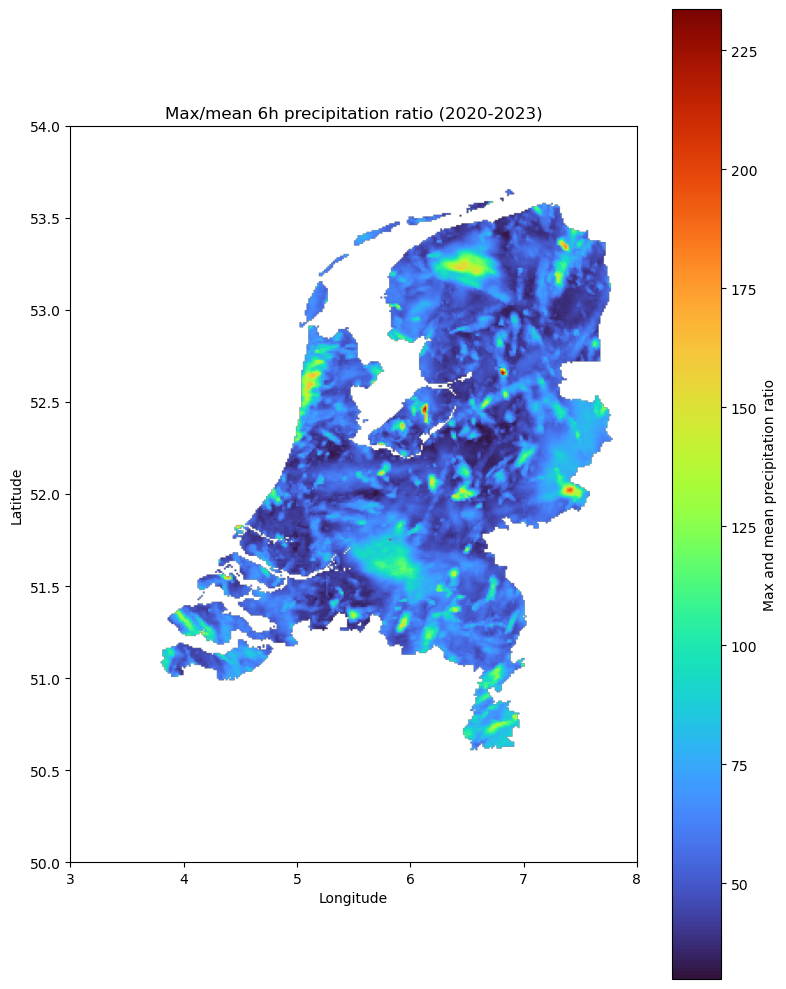

In [26]:
ratio_2d = max_2d / (mean_2d + 0.000001)

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(
    ratio_2d,
    cmap='turbo',
    origin='upper',
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    aspect=1 / np.cos(np.radians(52))
)
ax.set_xlim(3, 8)
ax.set_ylim(50, 54)
plt.colorbar(im, ax=ax, label='Max and mean precipitation ratio')
ax.set_title('Max/mean 6h precipitation ratio (2020-2023)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('max_mean_ratio_heatmap.png', dpi=150)
plt.show()

In [27]:
total = data.shape[0] * data.shape[1]

thresholds = [10, 25, 50, 75, 100, 125, 150, 175]

print(f"Total data points: {total:,}")
print(f"{'Threshold (mm/6h)':<20} {'Count':>12} {'Ratio (%)':>12}")
print("-" * 46)

for t in thresholds:
    count = (data > t).sum().compute()
    ratio = count / total * 100
    print(f"{t:<20} {int(count):>12,} {float(ratio):>12.4f}%")

Total data points: 3,129,462,000
Threshold (mm/6h)           Count    Ratio (%)
----------------------------------------------
10                      2,115,391       0.0676%
25                        100,580       0.0032%
50                          4,752       0.0002%
75                            694       0.0000%
100                           108       0.0000%
125                            13       0.0000%
150                             3       0.0000%
175                             1       0.0000%


In [ ]:
import pandas as pd

time_index = pd.date_range(start="2020-01-01", periods=data.sizes["time"], freq="6h")
data = data.assign_coords(time=time_index)



In [ ]:
# Daily totals (00:00 to 00:00), then max over time for each spatial point
daily = data.resample(time="1D").sum(min_count=4)
max_daily = daily.max(dim="time")
max_daily_2d = max_daily.values.reshape(765, 700)

# Yearly totals, then max over time for each spatial point
yearly = data.resample(time="1YS").sum(min_count=365)  # YS = year start (Jan 1)
max_yearly = yearly.max(dim="time")
max_yearly_2d = max_yearly.values.reshape(765, 700)

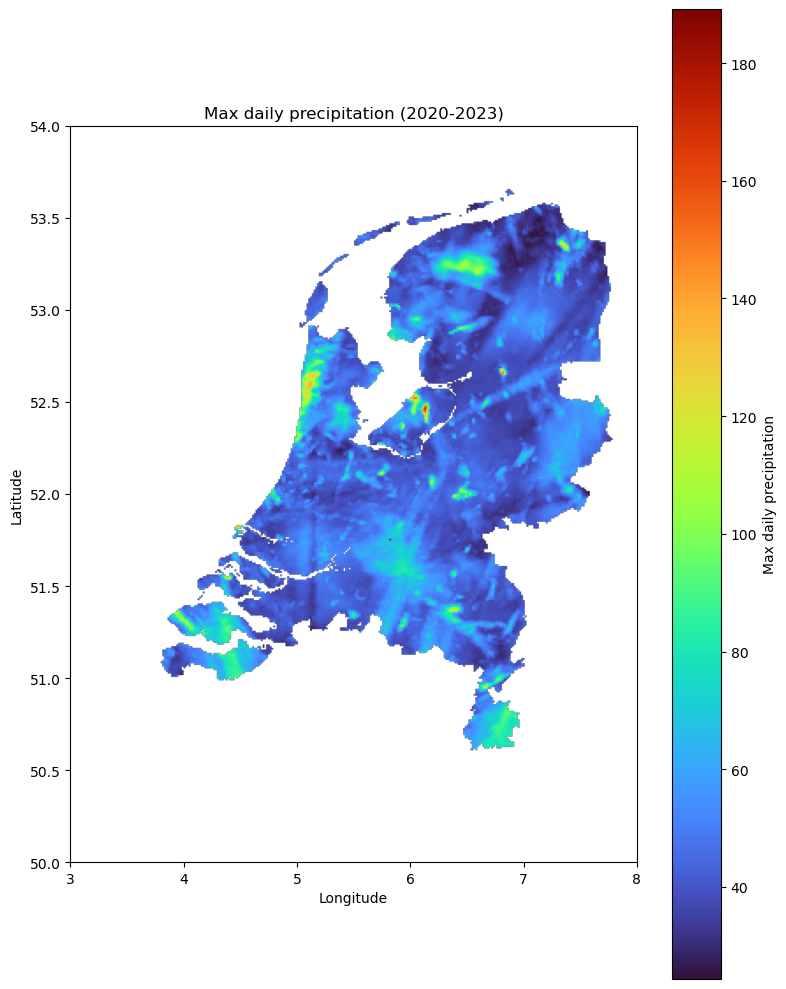

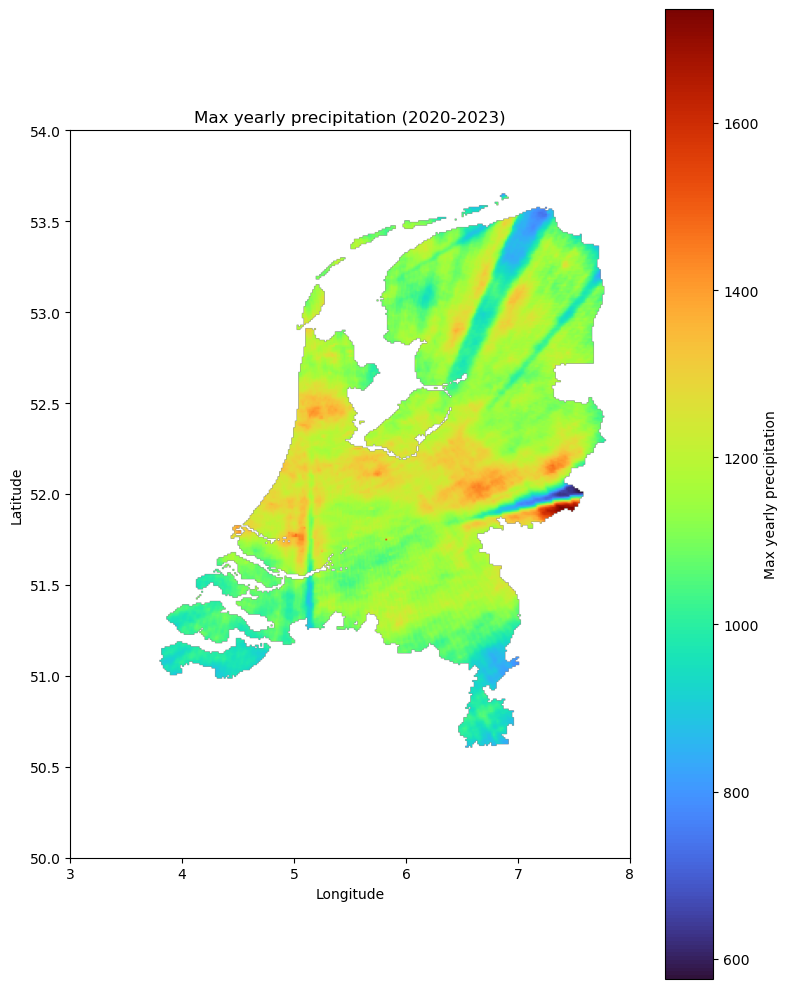

In [29]:
interval_name = 'daily'
for max_data_2d in [max_daily_2d, max_yearly_2d]:
    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.imshow(
        max_data_2d,
        cmap='turbo',
        origin='upper',
        extent=[lons.min(), lons.max(), lats.min(), lats.max()],
        aspect=1 / np.cos(np.radians(52))
    )
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    plt.colorbar(im, ax=ax, label=f"Max {interval_name} precipitation")
    ax.set_title(f"Max {interval_name} precipitation (2020-2023)")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.savefig(f"max_{interval_name}_heatmap.png", dpi=150)
    plt.show()
    interval_name = 'yearly'

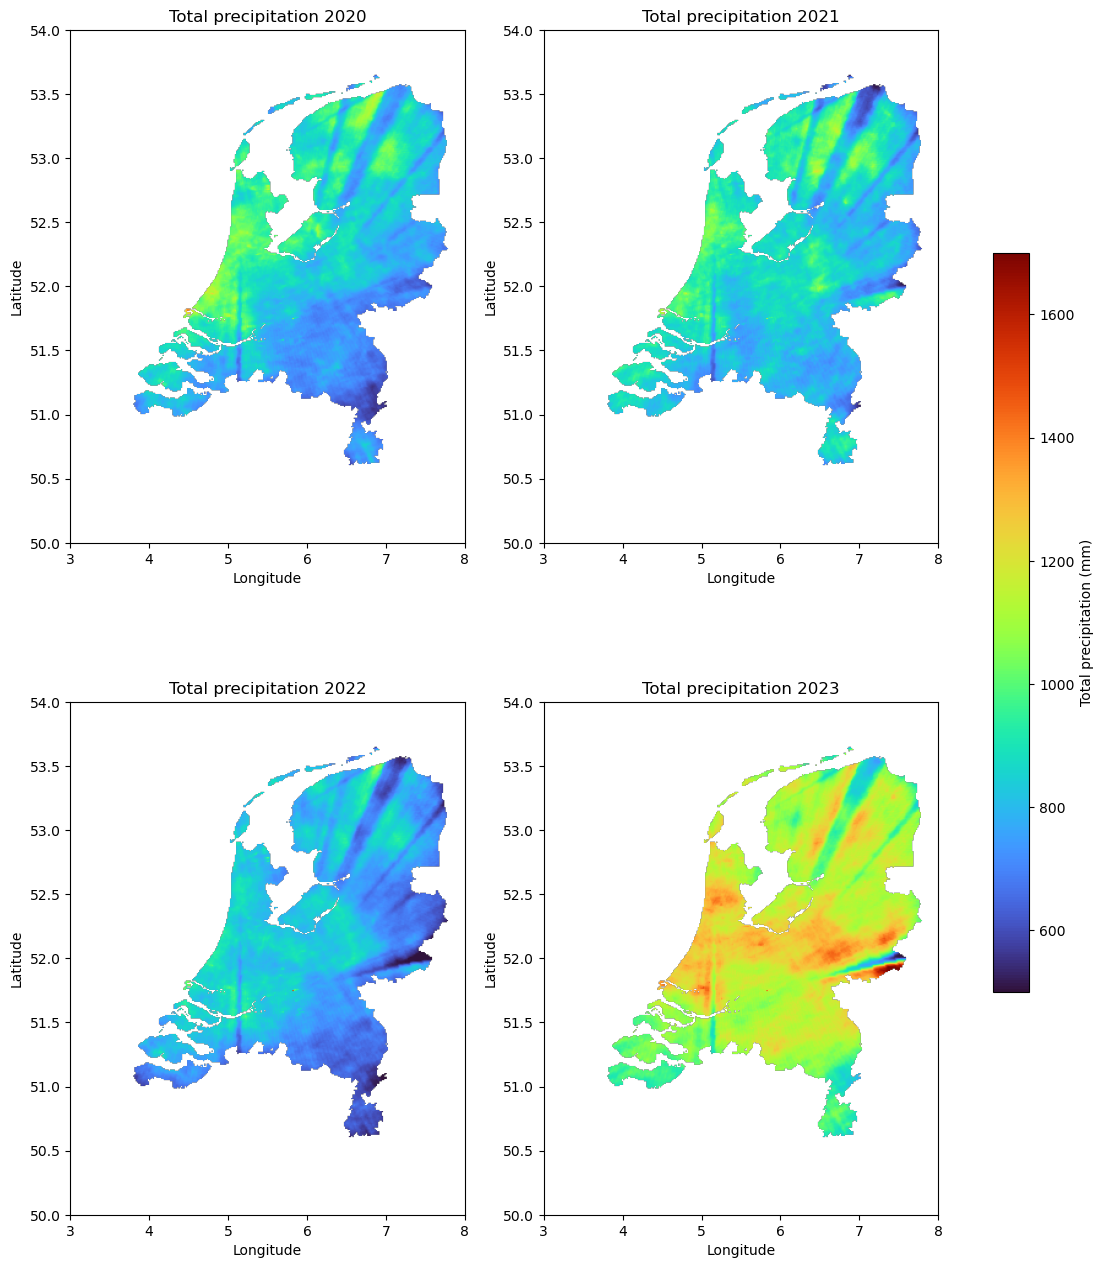

In [18]:
years = [2020, 2021, 2022, 2023]

vmin = 500
vmax = 1700

fig, axes = plt.subplots(2, 2, figsize=(14, 16))

for ax, year, da in zip(axes.flat, years, yearly):
    data_2d = da.values.reshape(765, 700)
    im = ax.imshow(
        data_2d,
        cmap='turbo',
        origin='upper',
        extent=[lons.min(), lons.max(), lats.min(), lats.max()],
        aspect=1 / np.cos(np.radians(52)),
        vmin=vmin, vmax=vmax
    )
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    ax.set_title(f"Total precipitation {year}")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

fig.colorbar(im, ax=axes, label="Total precipitation (mm)", shrink=0.6)
plt.savefig("yearly_precipitation_heatmaps.png", dpi=150)
plt.show()

504
863
15


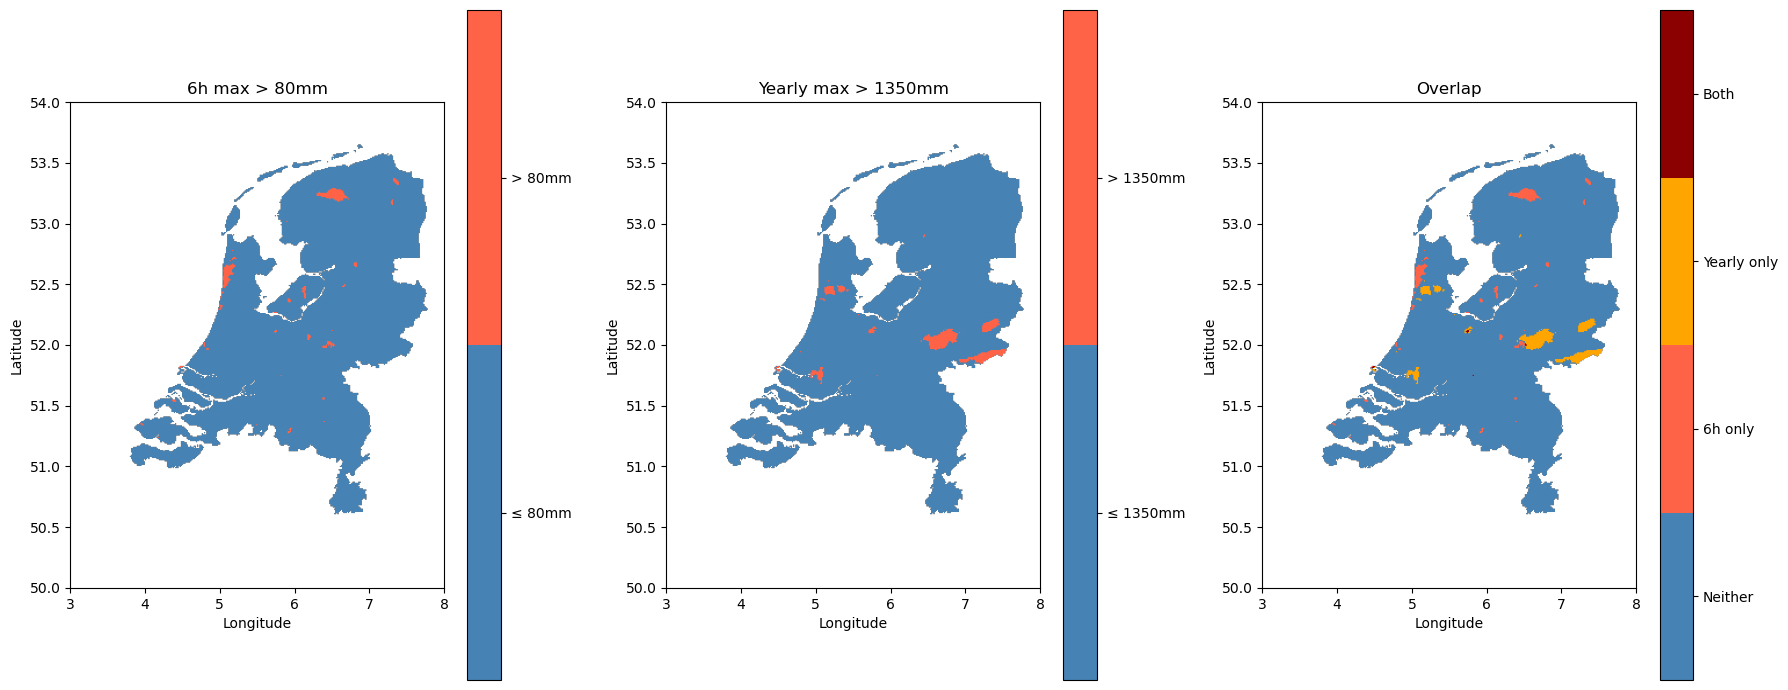

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 0 = does not exceed, 1 = exceeds, NaN = NaN
def make_category(mask, source):
    cat = np.where(np.isnan(source), np.nan,
                   np.where(mask, 1.0, 0.0))
    return cat

sixhourly_limit = 80
yearly_limit = 1350

mask_sixhourly  = max_2d  > sixhourly_limit
mask_yearly = max_yearly_2d > yearly_limit
mask_both   = mask_sixhourly & mask_yearly

print(mask_sixhourly.sum())
print(mask_yearly.sum())
print(mask_both.sum())


cat_sixhourly  = make_category(mask_sixhourly,  max_2d)
cat_yearly = make_category(mask_yearly, max_yearly_2d)

# 0 = neither, 1 = 6h only, 2 = yearly only, 3 = both
cat_overlap = np.full(max_2d.shape, np.nan)
valid = ~np.isnan(max_2d) & ~np.isnan(max_yearly_2d)
cat_overlap[valid] = (mask_sixhourly[valid].astype(int) +
                      mask_yearly[valid].astype(int) * 2)

cmap_binary  = mcolors.ListedColormap(["steelblue", "tomato"])
cmap_overlap = mcolors.ListedColormap(["steelblue", "tomato", "orange", "darkred"])

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

kwargs = dict(origin="upper",
              extent=[lons.min(), lons.max(), lats.min(), lats.max()],
              aspect=1 / np.cos(np.radians(52)))

# 6h
im0 = axes[0].imshow(cat_sixhourly, cmap=cmap_binary, vmin=0, vmax=1, **kwargs)
cbar0 = plt.colorbar(im0, ax=axes[0], ticks=[0.25, 0.75])
cbar0.ax.set_yticklabels([f"≤ {sixhourly_limit}mm", f"> {sixhourly_limit}mm"])
axes[0].set_title(f"6h max > {sixhourly_limit}mm")

# Yearly
im1 = axes[1].imshow(cat_yearly, cmap=cmap_binary, vmin=0, vmax=1, **kwargs)
cbar1 = plt.colorbar(im1, ax=axes[1], ticks=[0.25, 0.75])
cbar1.ax.set_yticklabels([f"≤ {yearly_limit}mm", f"> {yearly_limit}mm"])
axes[1].set_title(f"Yearly max > {yearly_limit}mm")

# Overlap
im2 = axes[2].imshow(cat_overlap, cmap=cmap_overlap, vmin=0, vmax=3, **kwargs)
cbar2 = plt.colorbar(im2, ax=axes[2], ticks=[0.375, 1.125, 1.875, 2.625])
cbar2.ax.set_yticklabels(["Neither", "6h only", "Yearly only", "Both"])
axes[2].set_title("Overlap")

for ax in axes:
    ax.set_xlim(3, 8)
    ax.set_ylim(50, 54)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(f"threshold_maps_{sixhourly_limit}_{yearly_limit}.png", dpi=150)
plt.show()

In [40]:
daily_vals = daily.values  # shape (time, space) or (time, y, x)

max_day_val = np.nanmax(daily_vals, axis=0)
max_day_idx = np.full(max_day_val.shape, -1, dtype=int)

valid_mask = ~np.isnan(max_day_val)
max_day_idx[valid_mask] = np.nanargmax(daily_vals[:, valid_mask], axis=0)

dates = np.empty(max_day_val.flatten().shape, dtype="datetime64[ns]")
idx_flat   = max_day_idx.flatten()
valid_flat = valid_mask.flatten()

dates[valid_flat]  = daily.time.values[idx_flat[valid_flat]]
dates[~valid_flat] = np.datetime64("NaT")

import pandas as pd

df = pd.DataFrame({
    "date":         dates,
    "lon":          lons.flatten(),
    "lat":          lats.flatten(),
    "max_daily_mm": max_day_val.flatten(),
})

df = df.dropna(subset=["max_daily_mm"])
df = df.sort_values("max_daily_mm", ascending=False).head(100).reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"]).dt.date

print(df.to_string())

          date       lon        lat  max_daily_mm
0   2022-08-02  5.232619  51.751513    189.179993
1   2020-08-14  5.616884  52.396462    181.580002
2   2020-08-14  5.615518  52.387895    164.780014
3   2020-08-14  5.618251  52.405030    157.900009
4   2021-06-03  6.274447  52.543030    154.750000
5   2020-08-14  5.614152  52.379328    153.889999
6   2020-08-14  5.539637  52.452392    153.290009
7   2020-08-14  5.601302  52.388648    149.709991
8   2020-08-14  5.553878  52.451638    148.679993
9   2020-08-14  5.632474  52.404276    146.940002
10  2020-08-14  5.602665  52.397216    146.529999
11  2020-08-14  5.525396  52.453147    144.369995
12  2020-08-14  5.599939  52.380081    142.319992
13  2021-06-03  6.272929  52.534472    139.560013
14  2021-06-18  4.695435  52.574898    138.610001
15  2020-08-14  5.631104  52.395709    138.309998
16  2021-06-18  4.708566  52.565560    138.020004
17  2021-06-18  4.709707  52.574141    137.619980
18  2021-06-18  4.694297  52.566316    136.270004
